# Amplitude encoding


In [1]:
import os
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as TFN
import torchquantum as tq
import torchquantum.functional as tqf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
OUT_DIR = Path("results_amplitude_encoding_lensing")

for subdir in ("figures", "tables", "logs", "arrays"):
    (OUT_DIR / subdir).mkdir(parents=True, exist_ok=True)

TRAIN_DIR = "/home/jovyan/ssh-test-datavol-1/dataset/dataset/train"
VAL_DIR = "/home/jovyan/ssh-test-datavol-1/dataset/dataset/val"

CLASS_NAMES = ["no", "sphere", "vort"]
CLASS_LONG = {
    "no": "no_substructure",
    "sphere": "spherical_substructure",
    "vort": "vortex_substructure",
}

N_QUBITS = 10
TARGET_SIZE = 32
assert 2**N_QUBITS == TARGET_SIZE * TARGET_SIZE


## Data


In [2]:
def load_lensing_dataset(
    roots,
    class_names=CLASS_NAMES,
    target_size=TARGET_SIZE,
    max_per_class=None,
):
    if isinstance(roots, (str, Path)):
        roots = [roots]

    files = []
    for split_idx, root_dir in enumerate(roots):
        root_dir = os.fspath(root_dir)
        if not os.path.isdir(root_dir):
            continue

        folders = sorted(
            name for name in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, name))
        )
        for class_name in class_names:
            if class_name not in folders:
                continue

            class_dir = os.path.join(root_dir, class_name)
            class_files = sorted(
                name for name in os.listdir(class_dir)
                if name.endswith(".npy")
            )
            if max_per_class is not None:
                class_files = class_files[:max_per_class]

            files.extend(
                (os.path.join(class_dir, name), class_name, split_idx)
                for name in class_files
            )

    if not files:
        raise FileNotFoundError(f"No .npy files found in {roots}")

    def to_2d(array):
        if array.ndim == 2:
            return array
        if array.ndim == 3:
            if array.shape[0] == 1:
                return array[0]
            if array.shape[0] == 3:
                return array.mean(axis=0)
            if array.shape[2] == 3:
                return array.mean(axis=2)
            if array.shape[2] == 1:
                return array[..., 0]
        raise ValueError(f"Unexpected array shape {array.shape}")

    n_files = len(files)
    X = np.empty((n_files, target_size * target_size), dtype=np.float32)
    y = np.empty(n_files, dtype=object)
    splits = np.empty(n_files, dtype=np.int8)
    batch_size = 256
    batch_indices = []
    batch_images = []

    for row_idx, (file_path, label, split_idx) in enumerate(files):
        image = to_2d(np.load(file_path)).astype(np.float32)
        if image.max() > 1.0:
            image = image / 255.0

        batch_images.append(image)
        batch_indices.append(row_idx)
        y[row_idx] = label
        splits[row_idx] = split_idx

        if len(batch_images) < batch_size and row_idx != n_files - 1:
            continue

        batch = np.stack(batch_images, axis=0)
        if batch.shape[1:] != (target_size, target_size):
            tensor = torch.from_numpy(batch).unsqueeze(1)
            tensor = TFN.interpolate(
                tensor,
                size=(target_size, target_size),
                mode="bilinear",
                align_corners=False,
            )
            batch = tensor.squeeze(1).numpy()

        for local_idx, global_idx in enumerate(batch_indices):
            X[global_idx] = batch[local_idx].reshape(-1)

        batch_indices = []
        batch_images = []

    return X, y, splits


## State preparation


In [3]:
X_raw, y, splits = load_lensing_dataset(
    VAL_DIR,
    class_names=CLASS_NAMES,
    target_size=TARGET_SIZE,
)

norms = np.linalg.norm(X_raw, axis=1)
valid = norms > 1e-12
if not valid.all():
    X_raw = X_raw[valid]
    y = y[valid]
    splits = splits[valid]
    norms = norms[valid]

X_amp = X_raw.astype(np.float64) / norms[:, None]
plus_state = np.ones(X_amp.shape[1], dtype=np.float64) / np.sqrt(X_amp.shape[1])
class_counts = {class_name: int((y == class_name).sum()) for class_name in CLASS_NAMES}
cs_present = [class_name for class_name in CLASS_NAMES if class_counts[class_name] > 0]
min_class_count = min(class_counts[class_name] for class_name in cs_present)

np.save(OUT_DIR / "arrays" / "X_amp.npy", X_amp.astype(np.float32))
np.save(OUT_DIR / "arrays" / "y.npy", y)
np.save(OUT_DIR / "arrays" / "plus_state.npy", plus_state.astype(np.float32))


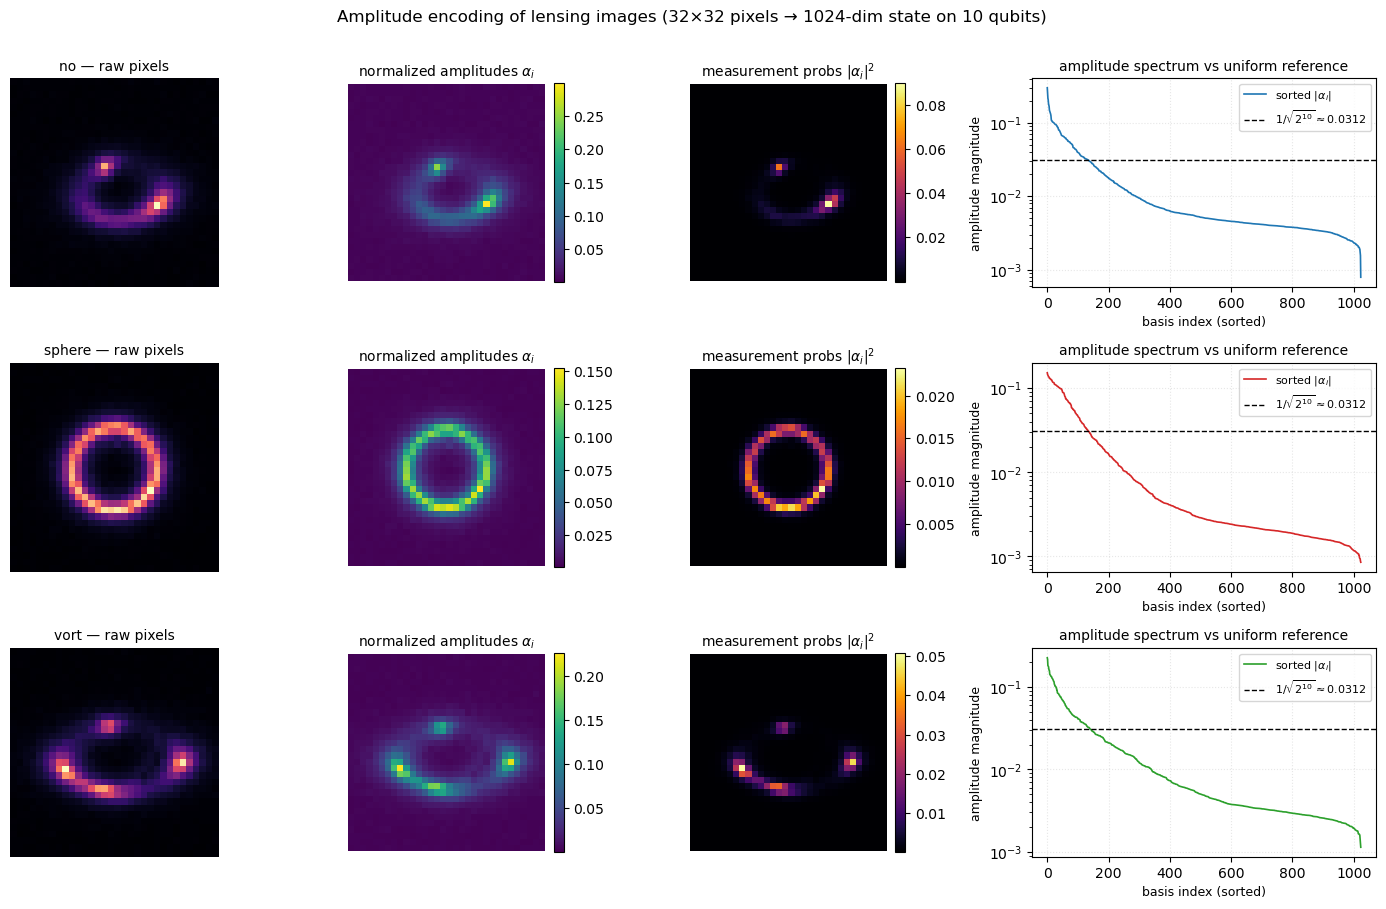

In [16]:
EXAMPLES_PER_CLASS = 1
n_rows = len(cs_present) * EXAMPLES_PER_CLASS
flat_dim = X_amp.shape[1]
uniform_amp = 1.0 / np.sqrt(flat_dim)

fig, axes = plt.subplots(
    n_rows, 4,
    figsize=(14, 3.0 * n_rows),
    gridspec_kw={"width_ratios": [1.0, 1.0, 1.0, 1.6]},
)
if n_rows == 1:
    axes = axes[None, :]

rng_examples = np.random.default_rng(SEED)
row = 0
for class_name in cs_present:
    class_pool = np.where(y == class_name)[0]
    chosen = rng_examples.choice(class_pool, size=EXAMPLES_PER_CLASS, replace=False)

    for sample_idx in chosen:
        raw_img = X_raw[sample_idx].reshape(TARGET_SIZE, TARGET_SIZE)
        amp_img = X_amp[sample_idx].reshape(TARGET_SIZE, TARGET_SIZE)
        prob_img = amp_img ** 2

        ax_raw, ax_amp, ax_prob, ax_spec = axes[row]

        ax_raw.imshow(raw_img, cmap="magma")
        ax_raw.set_title(f"{class_name} — raw pixels", fontsize=10)
        ax_raw.set_axis_off()

        im_amp = ax_amp.imshow(amp_img, cmap="viridis")
        ax_amp.set_title(r"normalized amplitudes $\alpha_i$", fontsize=10)
        ax_amp.set_axis_off()
        plt.colorbar(im_amp, ax=ax_amp, fraction=0.046, pad=0.04)

        im_prob = ax_prob.imshow(prob_img, cmap="inferno", norm=None)
        ax_prob.set_title(r"measurement probs $|\alpha_i|^2$", fontsize=10)
        ax_prob.set_axis_off()
        plt.colorbar(im_prob, ax=ax_prob, fraction=0.046, pad=0.04)

        sorted_amp = np.sort(np.abs(X_amp[sample_idx]))[::-1]
        ax_spec.plot(sorted_amp, color=CLASS_COLORS.get(class_name, "#1f77b4")
                     if "CLASS_COLORS" in globals() else "#1f77b4",
                     linewidth=1.2, label=r"sorted $|\alpha_i|$")
        ax_spec.axhline(uniform_amp, color="black", linestyle="--", linewidth=1.0,
                        label=fr"$1/\sqrt{{2^{{{N_QUBITS}}}}} \approx {uniform_amp:.4f}$")
        ax_spec.set_xlabel("basis index (sorted)", fontsize=9)
        ax_spec.set_ylabel("amplitude magnitude", fontsize=9)
        ax_spec.set_title("amplitude spectrum vs uniform reference", fontsize=10)
        ax_spec.set_yscale("log")
        ax_spec.grid(alpha=0.3, linestyle=":")
        ax_spec.legend(fontsize=8, loc="upper right")

        row += 1

plt.suptitle(
    f"Amplitude encoding of lensing images "
    f"({TARGET_SIZE}×{TARGET_SIZE} pixels → {flat_dim}-dim state on {N_QUBITS} qubits)",
    fontsize=12, y=1.005,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "amplitude_encoding_overview.png",
            dpi=160, bbox_inches="tight")
plt.show()


## Encoder check


In [5]:
rng = np.random.default_rng(SEED)
test_idx = rng.choice(len(X_raw), size=4, replace=False)
raw_test = X_raw[test_idx].astype(np.float32)
manual_amp = raw_test / np.linalg.norm(raw_test, axis=1, keepdims=True)

encoder = tq.StateEncoder()
qdev = tq.QuantumDevice(n_wires=N_QUBITS, bsz=4)
encoder(qdev, torch.from_numpy(raw_test))
tq_state = qdev.get_states_1d().detach().cpu().numpy()
state_norms = np.linalg.norm(tq_state, axis=1)

assert np.max(np.abs(tq_state.real - manual_amp)) < 1e-5
assert np.max(np.abs(tq_state.imag)) < 1e-5
assert np.max(np.abs(state_norms - 1.0)) < 1e-5


## Trace distance


In [6]:
TD_DTYPE = torch.float64


def trace_distance_lowrank_gpu(W, signs, eps=1e-12, device=DEVICE, dtype=TD_DTYPE):
    if not isinstance(W, torch.Tensor):
        W = torch.from_numpy(np.asarray(W))
    W = W.to(device=device, dtype=dtype)

    if not isinstance(signs, torch.Tensor):
        signs = torch.from_numpy(np.asarray(signs))
    signs = signs.to(device=device, dtype=dtype)

    gram = W @ W.T
    gram = 0.5 * (gram + gram.T)
    evals, evecs = torch.linalg.eigh(gram)
    keep = evals > eps
    if not keep.any():
        return 0.0

    root = torch.sqrt(evals[keep]).unsqueeze(1) * evecs[:, keep].T
    signed = (root * signs.unsqueeze(0)) @ root.T
    signed = 0.5 * (signed + signed.T)
    eigvals = torch.linalg.eigvalsh(signed)
    return float((0.5 * torch.abs(eigvals).sum()).item())


def trace_distance_classes_gpu(Va, Vb, device=DEVICE, dtype=TD_DTYPE):
    if not isinstance(Va, torch.Tensor):
        Va = torch.from_numpy(np.asarray(Va))
    if not isinstance(Vb, torch.Tensor):
        Vb = torch.from_numpy(np.asarray(Vb))

    Va = Va.to(device=device, dtype=dtype)
    Vb = Vb.to(device=device, dtype=dtype)
    n_a, n_b = Va.shape[0], Vb.shape[0]
    W = torch.cat([Va / np.sqrt(n_a), Vb / np.sqrt(n_b)], dim=0)
    signs = torch.cat(
        [
            torch.ones(n_a, dtype=dtype, device=device),
            -torch.ones(n_b, dtype=dtype, device=device),
        ]
    )
    return trace_distance_lowrank_gpu(W, signs, device=device, dtype=dtype)


def trace_distance_to_pure_gpu(V, u, device=DEVICE, dtype=TD_DTYPE):
    if not isinstance(V, torch.Tensor):
        V = torch.from_numpy(np.asarray(V))
    if not isinstance(u, torch.Tensor):
        u = torch.from_numpy(np.asarray(u))

    V = V.to(device=device, dtype=dtype)
    u = u.to(device=device, dtype=dtype)
    n_samples = V.shape[0]
    W = torch.cat([V / np.sqrt(n_samples), u.unsqueeze(0)], dim=0)
    signs = torch.cat(
        [
            torch.ones(n_samples, dtype=dtype, device=device),
            -torch.ones(1, dtype=dtype, device=device),
        ]
    )
    return trace_distance_lowrank_gpu(W, signs, device=device, dtype=dtype)


probe_W = torch.randn(8, 16, dtype=TD_DTYPE, device=DEVICE)
probe_signs = torch.tensor([1, 1, 1, 1, -1, -1, -1, -1], dtype=TD_DTYPE, device=DEVICE)
_ = trace_distance_lowrank_gpu(probe_W, probe_signs)


## Sweep


In [7]:
X_amp_gpu = torch.from_numpy(X_amp).to(device=DEVICE, dtype=TD_DTYPE)
plus_state_gpu = torch.from_numpy(plus_state).to(device=DEVICE, dtype=TD_DTYPE)

m_values_all = [10, 25, 50, 100, 250, 500, 750, 1000, 1500, 2000]
N_SEEDS = 5
m_values = [m for m in m_values_all if m <= min_class_count]
if not m_values:
    raise ValueError("No sample sizes fit the available class counts")

t0 = time.time()
rows = []

for m in m_values:
    for seed in range(N_SEEDS):
        rng = np.random.default_rng(SEED + 1000 * seed)
        sampled = {}

        for class_name in cs_present:
            idx = rng.choice(np.where(y == class_name)[0], size=m, replace=False)
            sampled[class_name] = torch.from_numpy(idx).to(device=DEVICE, dtype=torch.long)

        for class_name, idx in sampled.items():
            V = X_amp_gpu.index_select(0, idx)
            T = trace_distance_to_pure_gpu(V, plus_state_gpu)
            rows.append(
                {
                    "kind": "class_vs_plus",
                    "class_a": class_name,
                    "class_b": "|+>",
                    "m": m,
                    "seed": seed,
                    "T": T,
                }
            )

        for i, class_a in enumerate(cs_present):
            for class_b in cs_present[i + 1:]:
                Va = X_amp_gpu.index_select(0, sampled[class_a])
                Vb = X_amp_gpu.index_select(0, sampled[class_b])
                T = trace_distance_classes_gpu(Va, Vb)
                rows.append(
                    {
                        "kind": "between_classes",
                        "class_a": class_a,
                        "class_b": class_b,
                        "m": m,
                        "seed": seed,
                        "T": T,
                    }
                )

if torch.cuda.is_available():
    torch.cuda.synchronize()

sweep_seconds = time.time() - t0
df = pd.DataFrame(rows)
df.to_csv(OUT_DIR / "tables" / "beyond_mnist_section_3_3_raw.csv", index=False)

g = (
    df.groupby(["kind", "class_a", "class_b", "m"])["T"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
g.to_csv(OUT_DIR / "tables" / "beyond_mnist_section_3_3_summary.csv", index=False)


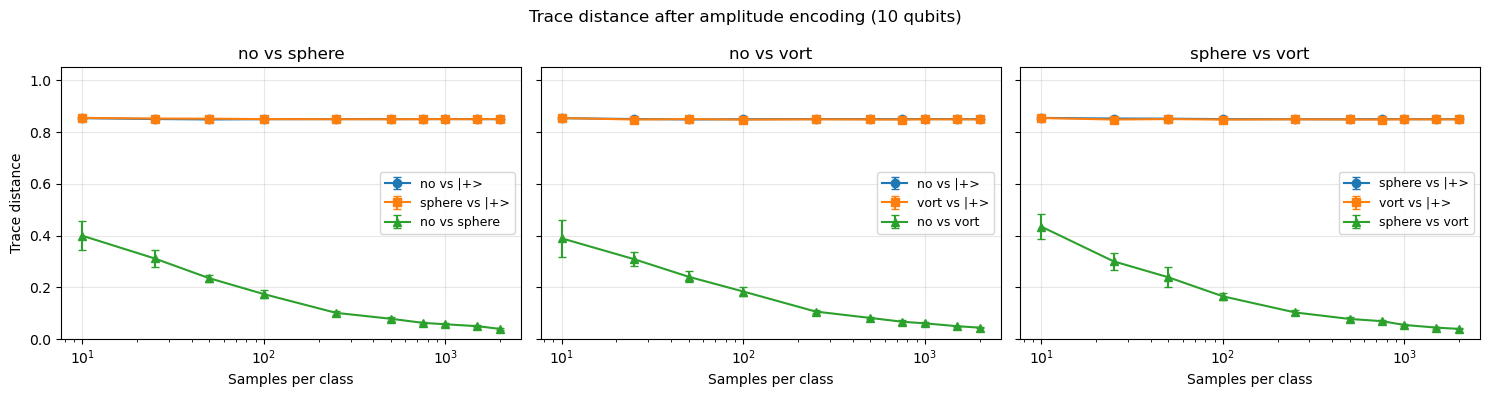

In [8]:
pairs = [
    (cs_present[i], cs_present[j])
    for i in range(len(cs_present))
    for j in range(i + 1, len(cs_present))
]

fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4), sharey=True)
if len(pairs) == 1:
    axes = [axes]

for ax, (class_a, class_b) in zip(axes, pairs):
    sub_a = g[
        (g["kind"] == "class_vs_plus")
        & (g["class_a"] == class_a)
    ].sort_values("m")
    sub_b = g[
        (g["kind"] == "class_vs_plus")
        & (g["class_a"] == class_b)
    ].sort_values("m")
    sub_ab = g[
        (g["kind"] == "between_classes")
        & (g["class_a"] == class_a)
        & (g["class_b"] == class_b)
    ].sort_values("m")

    ax.errorbar(
        sub_a["m"],
        sub_a["mean"],
        yerr=sub_a["std"],
        marker="o",
        capsize=3,
        label=f"{class_a} vs |+>",
    )
    ax.errorbar(
        sub_b["m"],
        sub_b["mean"],
        yerr=sub_b["std"],
        marker="s",
        capsize=3,
        label=f"{class_b} vs |+>",
    )
    ax.errorbar(
        sub_ab["m"],
        sub_ab["mean"],
        yerr=sub_ab["std"],
        marker="^",
        capsize=3,
        label=f"{class_a} vs {class_b}",
    )
    ax.set_xscale("log")
    ax.set_xlabel("Samples per class")
    ax.set_title(f"{class_a} vs {class_b}")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Trace distance")
plt.suptitle(f"Trace distance after amplitude encoding ({N_QUBITS} qubits)")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "trace_distance_sweep.png", dpi=140)
plt.show()


## Circuit check


In [9]:
class FixedRandomPQC(nn.Module):
    def __init__(self, n_wires, n_layers=20, seed=0):
        super().__init__()
        self.n_wires = n_wires
        self.n_layers = n_layers
        rng = np.random.default_rng(seed)
        angles = rng.standard_normal(size=(n_layers, n_wires, 3)).astype(np.float32)
        self.angles = nn.Parameter(torch.from_numpy(angles), requires_grad=False)
        self.measure = tq.MeasureAll(tq.PauliZ)

    def forward(self, qdev):
        for layer_idx in range(self.n_layers):
            for wire in range(self.n_wires):
                tqf.rx(qdev, wires=wire, params=self.angles[layer_idx, wire, 0:1])
                tqf.ry(qdev, wires=wire, params=self.angles[layer_idx, wire, 1:2])
                tqf.rz(qdev, wires=wire, params=self.angles[layer_idx, wire, 2:3])
            for wire in range(self.n_wires):
                tqf.cnot(qdev, wires=[wire, (wire + 1) % self.n_wires])
        return self.measure(qdev)


def class_average_prob1_gpu(V_amp_gpu_idx, pqc, n_wires=N_QUBITS, batch_size=256, device=DEVICE):
    outputs = []
    for start in range(0, len(V_amp_gpu_idx), batch_size):
        batch = V_amp_gpu_idx[start:start + batch_size].to(torch.float32)
        qdev = tq.QuantumDevice(n_wires=n_wires, bsz=batch.shape[0], device=device)
        qdev.states = batch.to(torch.complex64).reshape((batch.shape[0],) + (2,) * n_wires)
        z = pqc(qdev)
        prob_one = (1.0 - z) / 2.0
        outputs.append(prob_one.detach().cpu().numpy())
    return np.concatenate(outputs, axis=0).mean(axis=0)


N_PQC = 5
N_LAYERS = 20
M_VERIFY = min(500, min_class_count)

rng_v = np.random.default_rng(SEED + 9999)
sampled_idx = {
    class_name: torch.from_numpy(
        rng_v.choice(np.where(y == class_name)[0], size=M_VERIFY, replace=False)
    ).to(device=DEVICE, dtype=torch.long)
    for class_name in cs_present
}

T_pair = {}
for i, class_a in enumerate(cs_present):
    for class_b in cs_present[i + 1:]:
        T_pair[(class_a, class_b)] = trace_distance_classes_gpu(
            X_amp_gpu.index_select(0, sampled_idx[class_a]),
            X_amp_gpu.index_select(0, sampled_idx[class_b]),
        )

verify_rows = []
for pqc_seed in range(N_PQC):
    pqc = FixedRandomPQC(N_QUBITS, n_layers=N_LAYERS, seed=pqc_seed).to(DEVICE).eval()
    p1 = {
        class_name: class_average_prob1_gpu(X_amp_gpu.index_select(0, idx), pqc)
        for class_name, idx in sampled_idx.items()
    }

    for i, class_a in enumerate(cs_present):
        for class_b in cs_present[i + 1:]:
            diffs = np.abs(p1[class_a] - p1[class_b])
            for qubit in range(N_QUBITS):
                verify_rows.append(
                    {
                        "pair": f"{class_a} vs {class_b}",
                        "pqc_seed": pqc_seed,
                        "qubit": qubit,
                        "abs_obs_diff": float(diffs[qubit]),
                        "T": float(T_pair[(class_a, class_b)]),
                        "bound_2T": float(2 * T_pair[(class_a, class_b)]),
                    }
                )

df_v = pd.DataFrame(verify_rows)
df_v.to_csv(OUT_DIR / "tables" / "beyond_mnist_holder_verification.csv", index=False)

g_v = (
    df_v.groupby("pair")
    .agg(
        max_abs_diff=("abs_obs_diff", "max"),
        mean_abs_diff=("abs_obs_diff", "mean"),
        T=("T", "first"),
        bound_2T=("bound_2T", "first"),
    )
    .reset_index()
)
g_v["bound_holds"] = g_v["max_abs_diff"] <= g_v["bound_2T"] + 1e-6
g_v.to_csv(OUT_DIR / "tables" / "circuit_bound_summary.csv", index=False)


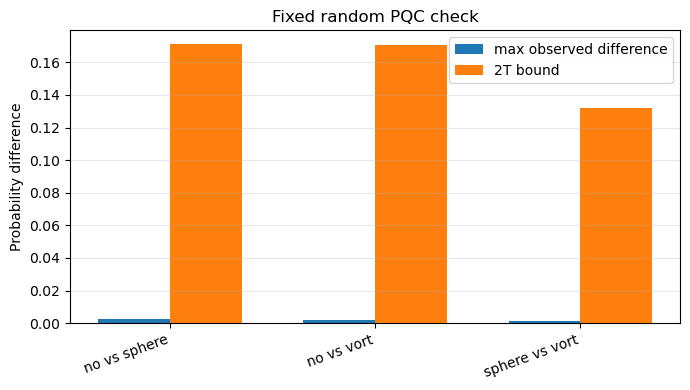

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(g_v))
width = 0.35

ax.bar(x - width / 2, g_v["max_abs_diff"], width, label="max observed difference")
ax.bar(x + width / 2, g_v["bound_2T"], width, label="2T bound")
ax.set_xticks(x)
ax.set_xticklabels(g_v["pair"], rotation=20, ha="right")
ax.set_ylabel("Probability difference")
ax.set_title("Fixed random PQC check")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "pqc_bound_check.png", dpi=140)
plt.show()


## Paper-style visualizations (Fig. 5 / Fig. 6 / Fig. 2b reproductions)

This section reproduces the key figures from
*"Beyond MNIST: Limitations of Amplitude Encoding on Quantum Classification"*
on our gravitational lensing dataset:

1. **Bloch sphere "globe"** (paper Fig. 5) — single-qubit reduction of the per-class
   averaged encoded state, showing where each class concentrates on the Bloch sphere.
2. **Trace-distance vs samples per class** (paper Fig. 6) — log-scaled, paper-style.
3. **Concentration difference vs sample size** (paper Fig. 2b / 3b / 4b) — how fast
   the observable expectation of the averaged encoded state collapses onto the
   superposition-state expectation as $M$ grows.

All plots reuse the variables defined above (`X_amp`, `y`, `cs_present`, `OUT_DIR`,
`plus_state`, `g`, `pairs`, `N_QUBITS`, …) so no extra data loading is required.

In [11]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3D projection)
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D

PAULI_X = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=np.complex128)
PAULI_Y = np.array([[0.0, -1.0j], [1.0j, 0.0]], dtype=np.complex128)
PAULI_Z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=np.complex128)


def reduced_single_qubit_rho(state_vec: np.ndarray, n_qubits: int, keep: int = 0) -> np.ndarray:
    """Partial trace of an n-qubit pure state vector down to one qubit.

    Args:
        state_vec: shape (2**n_qubits,) complex (or real) state vector.
        n_qubits: total number of qubits in the system.
        keep: index of the qubit to keep (0 = most-significant bit by reshape order).

    Returns:
        2x2 complex density matrix on the kept qubit.
    """
    psi = np.asarray(state_vec, dtype=np.complex128).reshape([2] * n_qubits)
    axes = [keep] + [q for q in range(n_qubits) if q != keep]
    psi = np.transpose(psi, axes).reshape(2, -1)
    return psi @ psi.conj().T


def bloch_vector(rho: np.ndarray) -> np.ndarray:
    """Bloch vector (x, y, z) of a single-qubit density matrix."""
    return np.array(
        [
            np.real(np.trace(PAULI_X @ rho)),
            np.real(np.trace(PAULI_Y @ rho)),
            np.real(np.trace(PAULI_Z @ rho)),
        ],
        dtype=np.float64,
    )


def draw_bloch_sphere(ax, color="#bdbdbd", alpha_surface=0.08, label_states=True):
    """Render a clean reference Bloch sphere with axis labels and equator."""
    u, v = np.mgrid[0:2 * np.pi:60j, 0:np.pi:30j]
    xs = np.cos(u) * np.sin(v)
    ys = np.sin(u) * np.sin(v)
    zs = np.cos(v)
    ax.plot_surface(xs, ys, zs, color=color, alpha=alpha_surface, linewidth=0)

    theta = np.linspace(0.0, 2.0 * np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), np.zeros_like(theta), color="black", lw=0.6, alpha=0.5)
    ax.plot(np.cos(theta), np.zeros_like(theta), np.sin(theta), color="black", lw=0.4, alpha=0.3)
    ax.plot(np.zeros_like(theta), np.cos(theta), np.sin(theta), color="black", lw=0.4, alpha=0.3)

    axis_kwargs = dict(color="black", lw=0.8, alpha=0.7)
    ax.plot([-1.05, 1.05], [0, 0], [0, 0], **axis_kwargs)
    ax.plot([0, 0], [-1.05, 1.05], [0, 0], **axis_kwargs)
    ax.plot([0, 0], [0, 0], [-1.05, 1.05], **axis_kwargs)

    if label_states:
        ax.text(0, 0, 1.18, r"$|0\rangle$", ha="center", va="center", fontsize=11)
        ax.text(0, 0, -1.22, r"$|1\rangle$", ha="center", va="center", fontsize=11)
        ax.text(1.22, 0, 0, r"$|+\rangle$", ha="center", va="center", fontsize=11)
        ax.text(-1.25, 0, 0, r"$|-\rangle$", ha="center", va="center", fontsize=11)
        ax.text(0, 1.22, 0, r"$|y+\rangle$", ha="center", va="center", fontsize=11)
        ax.text(0, -1.25, 0, r"$|y-\rangle$", ha="center", va="center", fontsize=11)

    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_zlim(-1.05, 1.05)
    ax.set_box_aspect((1.0, 1.0, 1.0))
    ax.set_axis_off()


CLASS_COLORS = {
    "no": "#1f77b4",
    "sphere": "#d62728",
    "vort": "#2ca02c",
}
CLASS_LABELS = {
    "no": "no substructure",
    "sphere": "spherical substructure",
    "vort": "vortex substructure",
}

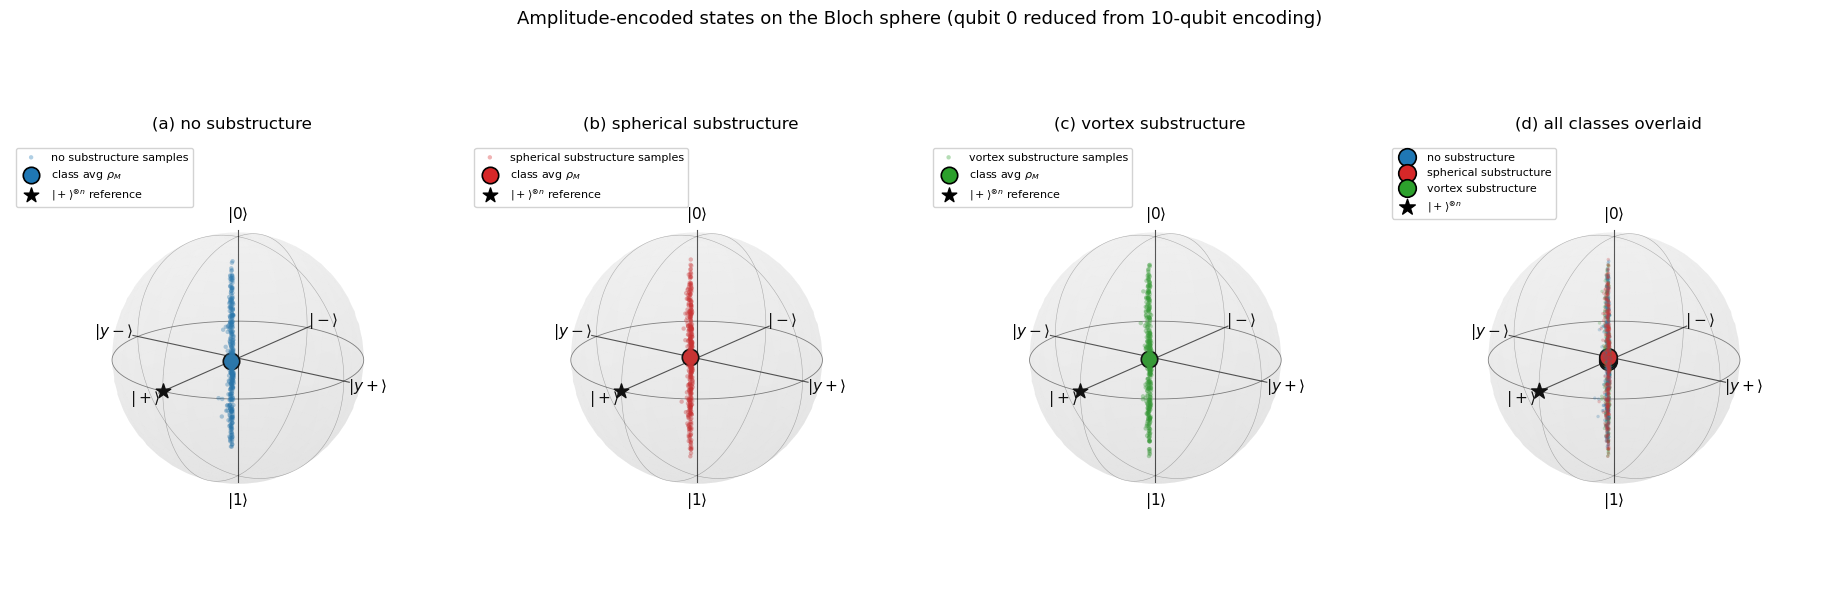

,class,bloch_x,bloch_y,bloch_z,bloch_norm,dist_to_plus,n_samples_used,kept_qubit
0,no,0.088953,0.0,0.001788,0.088971,0.911048,400,0
1,sphere,0.086389,0.0,0.030000,0.091449,0.914104,400,0
2,vort,0.087871,0.0,0.017205,0.089539,0.912292,400,0


In [12]:
BLOCH_SAMPLES_PER_CLASS = min(400, int(min_class_count))
BLOCH_KEEP_QUBIT = 0
rng_bloch = np.random.default_rng(SEED)

per_sample_bv = {}
class_avg_bv = {}

for class_name in cs_present:
    class_idx = np.where(y == class_name)[0]
    sampled_idx = rng_bloch.choice(class_idx, size=BLOCH_SAMPLES_PER_CLASS, replace=False)
    bvs = np.empty((BLOCH_SAMPLES_PER_CLASS, 3), dtype=np.float64)

    rho_mean_full = np.zeros((2, 2), dtype=np.complex128)
    for k, sample_idx in enumerate(sampled_idx):
        rho_single = reduced_single_qubit_rho(
            X_amp[sample_idx], n_qubits=N_QUBITS, keep=BLOCH_KEEP_QUBIT
        )
        bvs[k] = bloch_vector(rho_single)
        rho_mean_full += rho_single

    rho_mean_full /= BLOCH_SAMPLES_PER_CLASS
    per_sample_bv[class_name] = bvs
    class_avg_bv[class_name] = bloch_vector(rho_mean_full)

plus_rho = reduced_single_qubit_rho(plus_state, n_qubits=N_QUBITS, keep=BLOCH_KEEP_QUBIT)
plus_bv = bloch_vector(plus_rho)

fig = plt.figure(figsize=(5.5 * len(cs_present) + 2, 6.5))

for col, class_name in enumerate(cs_present):
    ax = fig.add_subplot(1, len(cs_present) + 1, col + 1, projection="3d")
    draw_bloch_sphere(ax)

    bvs = per_sample_bv[class_name]
    color = CLASS_COLORS.get(class_name, "#1f77b4")

    ax.scatter(
        bvs[:, 0], bvs[:, 1], bvs[:, 2],
        s=10, color=color, alpha=0.35, edgecolors="none",
        label=f"{CLASS_LABELS.get(class_name, class_name)} samples",
    )

    avg = class_avg_bv[class_name]
    ax.scatter(
        [avg[0]], [avg[1]], [avg[2]],
        s=140, color=color, edgecolors="black", linewidths=1.2,
        depthshade=False, label=r"class avg $\rho_M$",
    )
    ax.plot([0, avg[0]], [0, avg[1]], [0, avg[2]],
            color=color, lw=2.0, alpha=0.9)

    ax.scatter(
        [plus_bv[0]], [plus_bv[1]], [plus_bv[2]],
        s=120, marker="*", color="black",
        depthshade=False, label=r"$|+\rangle^{\otimes n}$ reference",
    )

    ax.set_title(
        f"({chr(ord('a') + col)}) {CLASS_LABELS.get(class_name, class_name)}",
        fontsize=12, pad=10,
    )
    ax.view_init(elev=18, azim=35)
    ax.legend(loc="upper left", fontsize=8, framealpha=0.85)

ax_all = fig.add_subplot(1, len(cs_present) + 1, len(cs_present) + 1, projection="3d")
draw_bloch_sphere(ax_all)
for class_name in cs_present:
    color = CLASS_COLORS.get(class_name, "#1f77b4")
    bvs = per_sample_bv[class_name]
    ax_all.scatter(
        bvs[:, 0], bvs[:, 1], bvs[:, 2],
        s=6, color=color, alpha=0.25, edgecolors="none",
    )
    avg = class_avg_bv[class_name]
    ax_all.scatter(
        [avg[0]], [avg[1]], [avg[2]],
        s=160, color=color, edgecolors="black", linewidths=1.2,
        depthshade=False, label=CLASS_LABELS.get(class_name, class_name),
    )
ax_all.scatter(
    [plus_bv[0]], [plus_bv[1]], [plus_bv[2]],
    s=140, marker="*", color="black", depthshade=False,
    label=r"$|+\rangle^{\otimes n}$",
)
ax_all.set_title(f"({chr(ord('a') + len(cs_present))}) all classes overlaid", fontsize=12, pad=10)
ax_all.view_init(elev=18, azim=35)
ax_all.legend(loc="upper left", fontsize=8, framealpha=0.85)

fig.suptitle(
    "Amplitude-encoded states on the Bloch sphere "
    f"(qubit {BLOCH_KEEP_QUBIT} reduced from {N_QUBITS}-qubit encoding)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "bloch_sphere_concentration.png", dpi=180, bbox_inches="tight")
plt.show()

bv_rows = []
for class_name in cs_present:
    avg = class_avg_bv[class_name]
    bv_rows.append({
        "class": class_name,
        "bloch_x": float(avg[0]),
        "bloch_y": float(avg[1]),
        "bloch_z": float(avg[2]),
        "bloch_norm": float(np.linalg.norm(avg)),
        "dist_to_plus": float(np.linalg.norm(avg - plus_bv)),
        "n_samples_used": BLOCH_SAMPLES_PER_CLASS,
        "kept_qubit": BLOCH_KEEP_QUBIT,
    })
bloch_df = pd.DataFrame(bv_rows)
bloch_df.to_csv(OUT_DIR / "tables" / "bloch_sphere_class_means.csv", index=False)
bloch_df

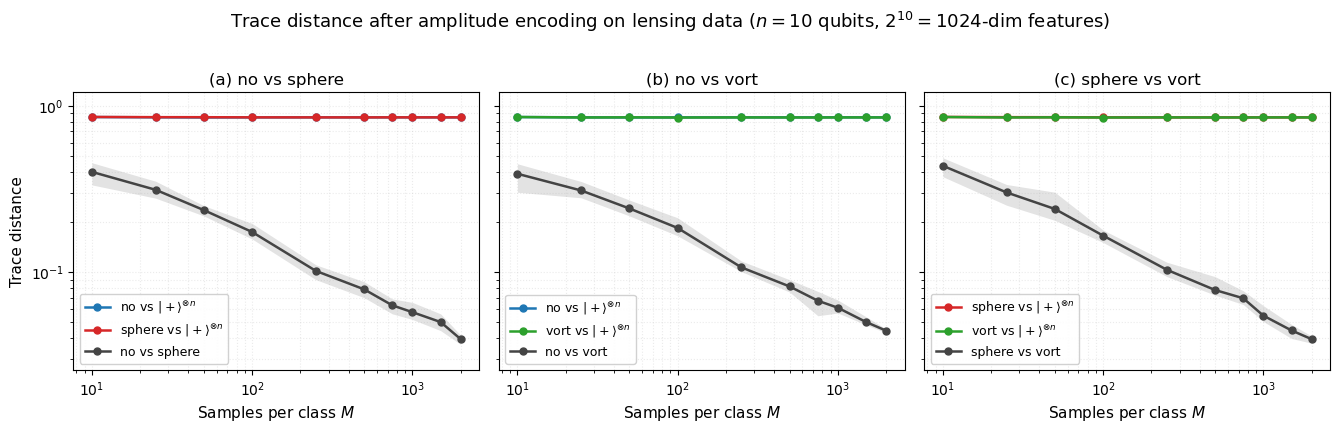

In [13]:
raw_stats = (
    df.groupby(["kind", "class_a", "class_b", "m"])["T"]
    .agg(["mean", "min", "max", "std", "count"])
    .reset_index()
)

n_pairs = len(pairs)
fig, axes = plt.subplots(
    1, n_pairs,
    figsize=(4.5 * n_pairs, 4.2),
    sharey=True,
)
if n_pairs == 1:
    axes = [axes]

paper_style = dict(
    linewidth=1.8,
    marker="o",
    markersize=5,
)

for ax, (class_a, class_b) in zip(axes, pairs):
    sub_a = raw_stats[
        (raw_stats["kind"] == "class_vs_plus") & (raw_stats["class_a"] == class_a)
    ].sort_values("m")
    sub_b = raw_stats[
        (raw_stats["kind"] == "class_vs_plus") & (raw_stats["class_a"] == class_b)
    ].sort_values("m")
    sub_ab = raw_stats[
        (raw_stats["kind"] == "between_classes")
        & (raw_stats["class_a"] == class_a)
        & (raw_stats["class_b"] == class_b)
    ].sort_values("m")

    color_a = CLASS_COLORS.get(class_a, "#1f77b4")
    color_b = CLASS_COLORS.get(class_b, "#d62728")
    color_ab = "#444444"

    for sub, color, label in [
        (sub_a, color_a, f"{class_a} vs $|+\\rangle^{{\\otimes n}}$"),
        (sub_b, color_b, f"{class_b} vs $|+\\rangle^{{\\otimes n}}$"),
        (sub_ab, color_ab, f"{class_a} vs {class_b}"),
    ]:
        ax.fill_between(
            sub["m"], sub["min"], sub["max"],
            color=color, alpha=0.15, linewidth=0,
        )
        ax.plot(sub["m"], sub["mean"], color=color, label=label, **paper_style)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Samples per class $M$", fontsize=11)
    ax.set_title(f"({chr(ord('a') + pairs.index((class_a, class_b)))}) "
                 f"{class_a} vs {class_b}", fontsize=12)
    ax.grid(which="both", alpha=0.25, linestyle=":")
    ax.set_ylim(max(1e-3, raw_stats["min"].min() * 0.7), 1.2)
    ax.legend(fontsize=9, loc="best", framealpha=0.9)

axes[0].set_ylabel("Trace distance", fontsize=11)
fig.suptitle(
    f"Trace distance after amplitude encoding on lensing data "
    f"($n={N_QUBITS}$ qubits, $2^{{{N_QUBITS}}}={2 ** N_QUBITS}$-dim features)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "trace_distance_paper_style.png",
            dpi=180, bbox_inches="tight")
plt.show()

In [14]:
DIFF_M_VALUES = [m for m in [10, 25, 50, 100, 250, 500, 750, 1000, 1500, 2000]
                 if m <= int(min_class_count)]
DIFF_N_PQC = 5
DIFF_N_LAYERS = 20
DIFF_OBS_QUBIT = 0

plus_idx = torch.from_numpy(np.array([0], dtype=np.int64)).to(DEVICE)
plus_state_batch = torch.from_numpy(plus_state[None, :]).to(device=DEVICE, dtype=torch.float32)

diff_rows = []

for pqc_seed in range(DIFF_N_PQC):
    pqc_diff = FixedRandomPQC(N_QUBITS, n_layers=DIFF_N_LAYERS,
                              seed=SEED + 7 * pqc_seed).to(DEVICE).eval()
    p1_plus_arr = class_average_prob1_gpu(plus_state_batch, pqc_diff)
    p1_plus = float(p1_plus_arr[DIFF_OBS_QUBIT])

    for m in DIFF_M_VALUES:
        for sample_seed in range(N_SEEDS):
            rng_local = np.random.default_rng(SEED + 31 * sample_seed + 7919 * pqc_seed)
            for class_name in cs_present:
                pool = np.where(y == class_name)[0]
                if m > len(pool):
                    continue
                idx_np = rng_local.choice(pool, size=m, replace=False)
                idx_t = torch.from_numpy(idx_np).to(device=DEVICE, dtype=torch.long)
                batch_states = X_amp_gpu.index_select(0, idx_t).to(torch.float32)

                p1_class = class_average_prob1_gpu(batch_states, pqc_diff)
                diff_rows.append({
                    "class": class_name,
                    "m": m,
                    "pqc_seed": pqc_seed,
                    "sample_seed": sample_seed,
                    "p1_class": float(p1_class[DIFF_OBS_QUBIT]),
                    "p1_plus": p1_plus,
                    "diff": abs(float(p1_class[DIFF_OBS_QUBIT]) - p1_plus),
                })

df_diff = pd.DataFrame(diff_rows)
df_diff.to_csv(OUT_DIR / "tables" / "concentration_difference_raw.csv", index=False)

agg = (
    df_diff.groupby(["class", "m"])["diff"]
    .agg(["mean", "min", "max", "std", "count"])
    .reset_index()
    .sort_values(["class", "m"])
)
agg.to_csv(OUT_DIR / "tables" / "concentration_difference_summary.csv", index=False)
agg.head()

,class,m,mean,min,max,std,count
0,no,10,0.011680,0.005732,0.023063,0.004501,25
1,no,25,0.013760,0.008572,0.021696,0.003984,25
2,no,50,0.013579,0.007302,0.018289,0.003411,25
3,no,100,0.013088,0.008219,0.019017,0.003280,25
4,no,250,0.013359,0.008962,0.017455,0.002993,25


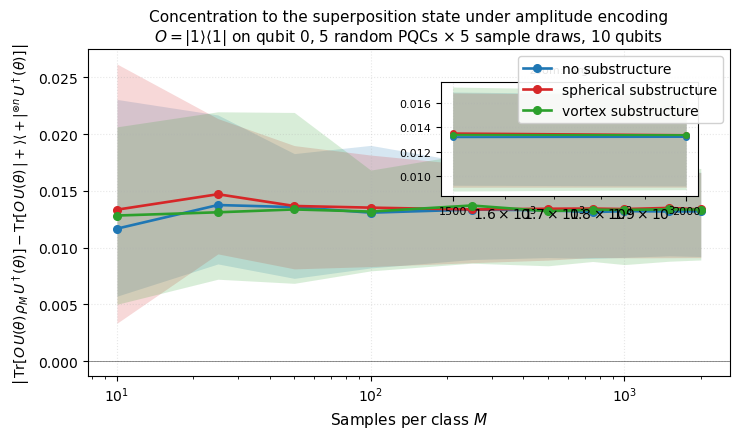

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))

for class_name in cs_present:
    sub = agg[agg["class"] == class_name].sort_values("m")
    if sub.empty:
        continue
    color = CLASS_COLORS.get(class_name, "#1f77b4")
    label = CLASS_LABELS.get(class_name, class_name)

    ax.fill_between(
        sub["m"], sub["min"], sub["max"],
        color=color, alpha=0.18, linewidth=0,
    )
    ax.plot(
        sub["m"], sub["mean"],
        color=color, marker="o", markersize=5.5,
        linewidth=1.9, label=label,
    )

ax.axhline(0.0, color="black", linewidth=0.6, alpha=0.5)
ax.set_xscale("log")
ax.set_xlabel("Samples per class $M$", fontsize=11)
ax.set_ylabel(
    r"$\left|\, \mathrm{Tr}[O\, U(\theta)\, \rho_M\, U^\dagger(\theta)]"
    r" - \mathrm{Tr}[O\, U(\theta)\, |+\rangle\langle+|^{\otimes n}\, U^\dagger(\theta)] \,\right|$",
    fontsize=10,
)
ax.set_title(
    f"Concentration to the superposition state under amplitude encoding\n"
    f"$O = |1\\rangle\\langle 1|$ on qubit {DIFF_OBS_QUBIT}, "
    f"{DIFF_N_PQC} random PQCs × {N_SEEDS} sample draws, "
    f"{N_QUBITS} qubits",
    fontsize=11,
)
ax.grid(alpha=0.3, linestyle=":")
ax.legend(fontsize=10, framealpha=0.9, loc="upper right")

if len(DIFF_M_VALUES) >= 4:
    last_two_m = DIFF_M_VALUES[-2:]
    inset = ax.inset_axes([0.55, 0.55, 0.4, 0.35])
    for class_name in cs_present:
        sub = agg[(agg["class"] == class_name) & (agg["m"].isin(last_two_m))]
        if sub.empty:
            continue
        color = CLASS_COLORS.get(class_name, "#1f77b4")
        inset.fill_between(sub["m"], sub["min"], sub["max"], color=color, alpha=0.18, linewidth=0)
        inset.plot(sub["m"], sub["mean"], color=color, marker="o", markersize=4, linewidth=1.5)
    inset.set_xscale("log")
    inset.set_xticks(last_two_m)
    inset.set_xticklabels([str(m) for m in last_two_m], fontsize=8)
    inset.tick_params(axis="y", labelsize=8)
    inset.grid(alpha=0.3, linestyle=":")
    inset.set_title("zoom: large $M$", fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "concentration_difference_vs_M.png",
            dpi=180, bbox_inches="tight")
plt.show()

### How to read the new figures

| Figure | File | What it shows |
| --- | --- | --- |
| Bloch sphere "globe" | `bloch_sphere_concentration.png` | Each class's $n$-qubit amplitude-encoded states partial-traced down to a single qubit. Small dots are individual samples; the large circle is the class mean $\rho_M$; the black star is the reference $\lvert+\rangle^{\otimes n}$ (which sits exactly at $+\hat{x}$). When the class clouds and the star all collapse near the same point, that is the **concentration phenomenon** the paper warns about. |
| Trace-distance, paper style | `trace_distance_paper_style.png` | Same data as the original sweep, but log-y, color-coded by class, with min/max bands. If the between-class curve sits well above $\sim 0.2$ and is flat, your data is *not* concentrating; if it sinks toward zero as $M$ grows, amplitude encoding is erasing the class-discriminating information. |
| Difference vs $M$ | `concentration_difference_vs_M.png` | Direct numerical reproduction of the paper's Fig. 2(b) / 3(b) / 4(b): $\bigl|\langle O\rangle_{\rho_M} - \langle O\rangle_{\lvert+\rangle\langle+\rvert^{\otimes n}}\bigr|$ with $O = \lvert 1\rangle\langle 1\rvert$ on qubit 0, averaged over `DIFF_N_PQC` random PQCs. Curves collapsing to zero confirm Proposition 3.2-type concentration for your dataset. |

All raw and summary CSVs are written under `OUT_DIR/tables/` so you can lift them straight into the paper or supplementary material.